# Crypto cross-sectional momentum

The selected momentum 90d strategy returned -10.11% over 01/2024-08/2026 after modelled transaction costs (25bp round trip), compared with -48.68% for the equal-weight benchmark on the same universe. However, its maximum drawdown was worse, and the 95% confidence interval for the Sharpe difference included zero. Hence no statistically significant edge has been shown over the equal-weight benchmark.

This notebook serves as a brief overview of the [original research notebook](archive/crypto_cross_sectional_research_2026-09-19.ipynb), preserving the main research pattern without all the nitty-gritty details.

### Imports and setup

Use the saved Coinbase daily USD candles and minute references, converting valuations into GBP using saved ECB exchange rates. No new requests are needed. Missing saved inputs should be restored, not replaced with a new download.

In [1]:
from pathlib import Path
from contextlib import redirect_stdout
import io
import json
import sys
import importlib
import pandas as pd
from IPython.display import display
%matplotlib inline

PROJECT_ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                    if (p / "research/weekly_sweep_protocol_v1.json").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import preparation, eligibility, universe_policy, features, selection, fx
import intraday, execution_inputs, weekly_sweep, weekly_walk_forward, inference

RAW_DIR = PROJECT_ROOT / "data/raw"
HISTORY_DIR = RAW_DIR / "coinbase_coverage_20260918T183827_526442Z"
FX_PATH = RAW_DIR / "ecb_gbp_usd_20260918T185616_488505Z.json"
MINUTE_DIR = RAW_DIR / "execution_minute_probe_v1"
WEEKLY_PROTOCOL = json.loads((PROJECT_ROOT / "research/weekly_sweep_protocol_v1.json").read_text())
weekly_sweep._check_protocol(WEEKLY_PROTOCOL)
display(pd.DataFrame(WEEKLY_PROTOCOL["folds"]).set_index("fold"))

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,test_end,test_start,training_end,training_start
fold,,,,
1,2025-01-01,2024-01-01,2024-01-01,2022-01-01
2,2026-01-01,2025-01-01,2025-01-01,2022-01-01
3,2026-09-01,2026-01-01,2026-01-01,2022-01-01


In [ ]:
import cost_stress
import plotting
import inference

## Data and universe

Begin with the saved Revolut X universe, excluding stablecoins, gold-backed tokens and memecoins. Coinbase USD pairs provide broader historical data than GBP pairs. The saved daily history contains 59 products before the meme exclusions.

At each decision, require 181 consecutive daily observations and at least $1m median daily volume over the previous 30 days. Retain at most the 30 most liquid eligible assets. If fewer than 20 qualify, both portfolios hold GBP cash.

XRP has a 904-day gap. History and signals restart after the gap. Historical eligibility uses information available at the time, but universe is current, hence survivorship bias is there.

In [ ]:
prices, history_spec = preparation.load_saved_daily_prices(HISTORY_DIR)
price_audit, missing_days = preparation.audit_daily_prices(prices)
issue_columns = ["internal_missing_days", "duplicates", "off_midnight", "nonfinite_rows", "nonpositive_price_rows", "invalid_ohlc_rows", "negative_volume_rows", "zero_volume_rows"]
display(price_audit[issue_columns].sum().rename("rows"))
display(missing_days.groupby("product_id").agg(first_missing=("timestamp", "min"), last_missing=("timestamp", "max"), missing_days=("timestamp", "size")))

eligibility_panel = eligibility.add_research_eligibility(prices, **WEEKLY_PROTOCOL["eligibility"])
policy_panel = universe_policy.apply_universe_policy(eligibility_panel)
policy_counts = policy_panel.groupby("signal_available_at")[["history_ready", "universe_candidate"]].sum()
check_dates = pd.to_datetime(["2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2024-01-01", "2025-01-01", "2026-01-01", "2026-09-01"], utc=True)
display(policy_counts.reindex(check_dates))

/Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/src/preparation.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prices = pd.concat(frames, ignore_index=True)


internal_missing_days     904
duplicates                  0
off_midnight                0
nonfinite_rows              0
nonpositive_price_rows      0
invalid_ohlc_rows           0
negative_volume_rows        0
zero_volume_rows            0
Name: rows, dtype: int64

,first_missing,last_missing,missing_days
product_id,,,
XRP-USD,2021-01-20 00:00:00+00:00,2023-07-12 00:00:00+00:00,904


,history_ready,universe_candidate
2020-01-01 00:00:00+00:00,8,6
2021-01-01 00:00:00+00:00,11,11
2022-01-01 00:00:00+00:00,21,20
2023-01-01 00:00:00+00:00,28,21
2024-01-01 00:00:00+00:00,36,29
2025-01-01 00:00:00+00:00,44,37
2026-01-01 00:00:00+00:00,54,33
2026-09-01 00:00:00+00:00,59,27


## Strategy and execution

The question we seek to answer is, can ranking cryptocurrencies by recent returns improve performance compared to holding the same eligible universe with equal weights? The economic hypothesis is that gradual changes in investor demand can sustain relative price trends. This is the economic motivation behind testing, and is not a reason why this strategy must work.


At midnight (UTC) Monday, each eligible's assets trailing (close to close) returns are calculated using daily candles. They are then ranked, and the top fraction are selected and given equal weight in the order. Unlike the previous BTC/ETH project, returns are ranked against other assets, as opposed to against zero. Negative-momentum winners can still be chosen.

The benchmark holds every asset in the same eligible universe with equal weights. It follows the same decision and rebalance schedule.

Use the first common time from 00:05, with the latest completed positive-volume minute candle for each targetted cryptocurrency. Its start must be no more than five minutes old.

In [ ]:
#initial 30d momentum, top 20% targets establish common universe. later sweep chooses parameters, but benchmark is unchanged
feature_panel = features.add_momentum_features(policy_panel, lookback_days=30)
weekly_universe, weekly_universe_summary = selection.build_weekly_universe(feature_panel, **WEEKLY_PROTOCOL["universe"])
_, momentum_targets, benchmark_targets = selection.build_momentum_targets(weekly_universe, weekly_universe_summary, top_fraction=.20)

fx_observations = fx.load_fx_history(FX_PATH)
gbp_prices, fx_alignment_audit = fx.build_gbp_valuation_prices(prices, fx_observations, max_age_days=7)
reference_targets = benchmark_targets.loc[(benchmark_targets.index >= prices.timestamp.min()) &(benchmark_targets.index <= prices.timestamp.max())].copy()
reference_request_plan = intraday.build_reference_request_plan(reference_targets, MINUTE_DIR)

#audit all saved windows
reference_log = io.StringIO()
with redirect_stdout(reference_log):
    execution_reference_report, capture_summary = intraday.capture_execution_references(reference_request_plan, MINUTE_DIR, allow_download=False,
        max_age_minutes=WEEKLY_PROTOCOL["execution_max_reference_age_minutes"])
    
if capture_summary["stop_reason"] != "complete":
    raise ValueError(f"Incomplete saved execution inputs: {capture_summary.to_dict()}")

reference_gaps = execution_reference_report.loc[
    ~execution_reference_report.reference_available, ["product_id", "day", "status"]]
with redirect_stdout(reference_log):
    extended_gap_report = intraday.inspect_extended_gaps(reference_gaps, MINUTE_DIR, allow_download=False)
assert extended_gap_report.original_window_matches.all()

affected_plan = reference_request_plan.loc[reference_request_plan.day.isin(reference_gaps.day)]
gap_schedule, gap_references = intraday.find_common_execution_references(affected_plan, MINUTE_DIR, window_minutes=15, allow_download=False)
hour_plan = affected_plan.loc[affected_plan.day.isin(gap_schedule.loc[gap_schedule.status.ne("ready"), "day"])]
hour_schedule, hour_references = intraday.find_common_execution_references(hour_plan, MINUTE_DIR, window_minutes=60, allow_download=False)

resolved_gap_schedule = pd.concat([gap_schedule.loc[gap_schedule.status.eq("ready")], hour_schedule], ignore_index=True).sort_values("day")
resolved_gap_references = pd.concat([gap_references, hour_references], ignore_index=True)
intraday_schedule, execution_references_usd = execution_inputs.assemble_execution_inputs(
reference_targets, reference_request_plan, execution_reference_report, resolved_gap_schedule, resolved_gap_references)

execution_references_gbp = execution_inputs.convert_execution_references_to_gbp(execution_references_usd, fx_observations, max_age_days=7)
needs_prices = intraday_schedule.required_assets.gt(0)

display(pd.Series({"reference_rows": len(execution_references_gbp),
    "dates_requiring_prices": int(needs_prices.sum()),
    "delayed_dates": int(intraday_schedule.delay_after_0005_minutes.gt(0).sum()),
    "cash_only_dates": int((~needs_prices).sum()), "new_requests": capture_summary["new_requests"]}))

reference_rows            6163
dates_requiring_prices     229
delayed_dates               16
cash_only_dates            171
new_requests                 0
dtype: int64

GBP prices are USD prices divided by USD per GBP. Each dated ECB rate is assumed available from the following midnight, with the latest available rate carried through weekends. This is a modelling assumption, such rate may not be available at that time.

9bp commission plus 3.5bp other execution costs per side, giving 25bp round trip. These are modelling assumptions for (intended) Revolut X usage. Fractional units allowed, no leverage or shorting, no interest on GBP cash and no forced final liquidation.

## Sweep and annual selection

Now sweep across 7, 14, 30, 60, 90 and 180 days of momentum, with top fractions of 10%, 20% and 30%. Rebalancing stays weekly. Daily, monthly rebalancing could possibly perform better, but are not tested here.

Select the configuration with the highest training Sharpe difference against the benchmark. Training begins on 01/01/2022 and expands each year, ending before that year's evaluation begins. Ties favour lower turnover, then shorter lookback, then smaller top fraction.

The first training period is 2022-2023. Subsequent annual choices use 2022-2024 and 2022-2025. This is an expanding walk-forward with training-only parameter selection.

In [ ]:
walk_forward_choices, fold_training_tables = weekly_walk_forward.select_annual_parameters(
    policy_panel, gbp_prices, intraday_schedule, execution_references_gbp, WEEKLY_PROTOCOL, progress=False)
training_ranked = weekly_sweep.rank_training_candidates(fold_training_tables[1])

display(training_ranked[["total_return", "sharpe_zero_cash_rate", "sharpe_difference", "max_drawdown", "annualised_one_way_turnover"]].style.format({
    "total_return": "{:.2%}", "sharpe_zero_cash_rate": "{:.3f}", "sharpe_difference": "{:+.3f}", "max_drawdown": "{:.2%}",
    "annualised_one_way_turnover": "{:.2f}"}))

display(walk_forward_choices[["lookback_days", "top_fraction", "training_end", "training_sharpe", "test_start", "test_end"]])

,lookback_days,top_fraction,training_end,training_sharpe,test_start,test_end
fold,,,,,,
1,90,0.1,2024-01-01 00:00:00+00:00,0.549706,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
2,90,0.1,2025-01-01 00:00:00+00:00,0.937699,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00
3,90,0.1,2026-01-01 00:00:00+00:00,0.519462,2026-01-01 00:00:00+00:00,2026-09-01 00:00:00+00:00


See that 90d momentum with the top 10% performs best in the first training period. It returned 19.50%, compared with -58.29% for the benchmark, but still suffered a drawdown of ~80%. Annual selection also chooses 90d, top 10% for both later years.

## Walk-forward evaluation: 2024-August 2026

Now evaluate the annual selections on the following periods. Start both portfolios from £1,000 cash on 01/01/2024, including entry costs. Run one continuous portfolio through 31/08/2026, of which there are 974 daily returns.

In [ ]:
walk_forward_runs, walk_forward_decision_audit, walk_forward_targets, walk_forward_benchmark_targets = weekly_walk_forward.run_walk_forward(
    policy_panel=policy_panel,
    gbp_prices=gbp_prices,
    execution_schedule=intraday_schedule,
    execution_references=execution_references_gbp,
    choices=walk_forward_choices,
    protocol=WEEKLY_PROTOCOL)

display(walk_forward_decision_audit.groupby("selection_fold").first()[[
        "selection_at",
        "decision_at",
        "execution_at",
        "lookback_days",
        "top_fraction"]])

walk_forward_summary = pd.DataFrame({name: weekly_sweep.summarise_training_ledger(
        ledger,start=WEEKLY_PROTOCOL["oos_start"], end=WEEKLY_PROTOCOL["oos_end"])
    for name, (ledger, trades, positions) in walk_forward_runs.items()}).T

display(walk_forward_summary[[
        "total_return",
        "cagr",
        "annualised_volatility",
        "sharpe_zero_cash_rate",
        "max_drawdown",
        "annualised_one_way_turnover"]].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}"}))

yearly_returns = pd.DataFrame({name: ledger["net_return"].groupby(ledger.index.year).apply(lambda returns: (1 + returns).prod() - 1)
    for name, (ledger, trades, positions) in walk_forward_runs.items()})
display(yearly_returns.style.format("{:.2%}"))

,selection_at,decision_at,execution_at,lookback_days,top_fraction
selection_fold,,,,,
1,2024-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00,2024-01-01 00:05:00+00:00,90,0.1
2,2025-01-01 00:00:00+00:00,2025-01-06 00:00:00+00:00,2025-01-06 00:05:00+00:00,90,0.1
3,2026-01-01 00:00:00+00:00,2026-01-05 00:00:00+00:00,2026-01-05 00:05:00+00:00,90,0.1


,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,annualised_one_way_turnover
walk_forward,-10.11%,-3.92%,87.38%,0.387,-86.79%,28.72
benchmark,-48.67%,-22.12%,74.75%,0.040,-81.87%,5.50


,walk_forward,benchmark
candle_start,,
2024,216.70%,62.17%
2025,-65.99%,-62.51%
2026,-16.54%,-15.59%


See that momentum performs much better in cumulative returns, but both portfolios lose money overall. Most of the relative advantage comes from 2024, with momentum returning 216.70%, compared with 62.17% for the benchmark. It then slightly underperformed the benchmark in both 2025 and 01-08/2026. The momentum strategy also has greater volatility and a worse maximum drawdown over the period.

Now compare the equity curves of both approaches.

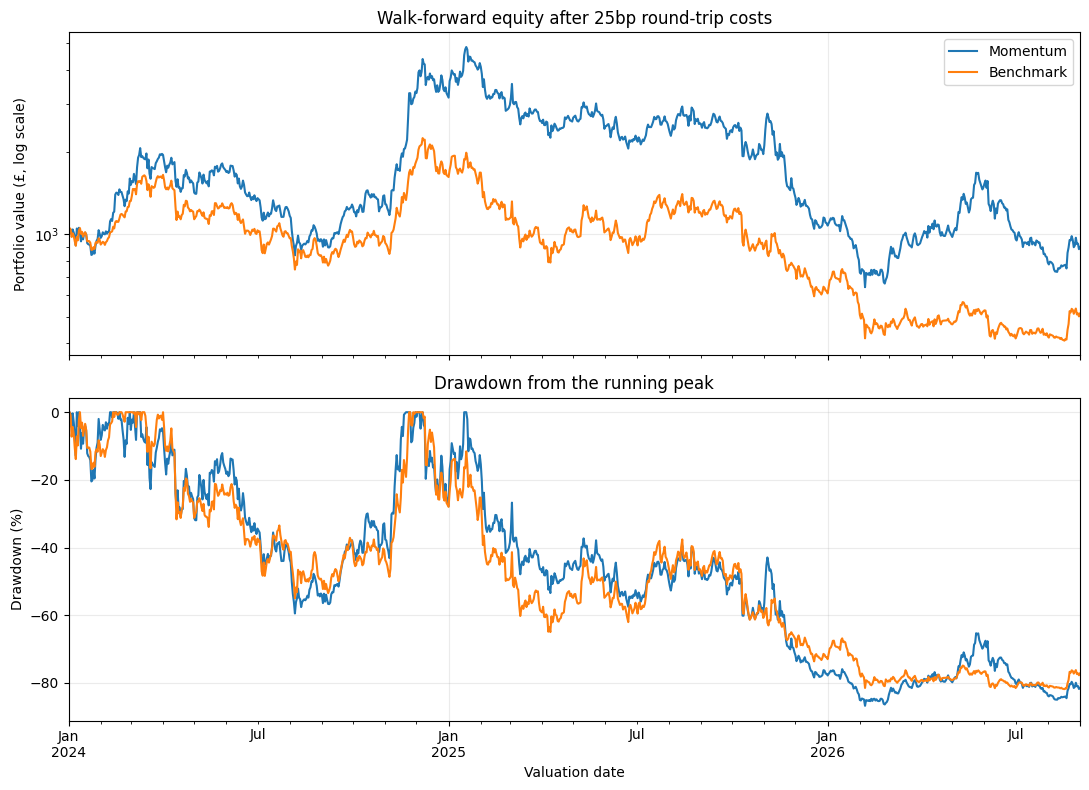

In [ ]:
importlib.reload(plotting)
fig, axes, equity, drawdown = plotting.plot_walk_forward_equity(walk_forward_runs, WEEKLY_PROTOCOL)

The equity curves tell the same story as the statistics. Momentum strategy performs better in 2024, and slightly worse in the remainder when compared with the benchmark.

## Significance testing

The primary statistic is the Sharpe difference, using a paired circular block bootstrap of daily net returns (10,000 resamples, 28-day blocks and a 95% percentile interval). Both portfolios use the same sampled dates. 14 and 56 days are used as sensitivities.

The frozen significance condition requires the primary interval's lower bound to be strictly positive. The bootstrap measures uncertainty in the realised return comparison.

In [ ]:
importlib.reload(inference)

edge_test, bootstrap_draws = inference.test_walk_forward_edge(walk_forward_runs, WEEKLY_PROTOCOL)
display(edge_test[["sharpe_difference", "ci_lower", "ci_upper"]].round(3))

,sharpe_difference,ci_lower,ci_upper
block_days,,,
28.0,0.347,-0.359,1.004
14.0,0.347,-0.323,0.987
56.0,0.347,-0.409,1.020


All three intervals contain zero. The primary Sharpe difference is +0.347, with a 95% interval of [-0.359, +1.004]. Hence no statistically significant edge has been shown against the benchmark. This does not prove that no advantage exists, but that the test is inconclusive.

## Transaction cost sensitivity

Now check sensitivity to 25, 40 and 60bp round-trip costs. Retain the annual selections made under the original 25bp assumption. Prices, targets and execution times also stay the same.

Commission stays at 9bp per side. Other execution costs rise from 3.5bp to 11bp and 21bp per side. Both the strategy and benchmark are charged the same cost assumptions.

In [ ]:

cost_summary, cost_runs = cost_stress.run_cost_stress(gbp_prices, walk_forward_targets, walk_forward_benchmark_targets,
intraday_schedule, execution_references_gbp, WEEKLY_PROTOCOL)

#25bp replay must reproduce the earlier ledgers
for name in walk_forward_runs:
    pd.testing.assert_frame_equal(cost_runs[(25.0, name)][0], walk_forward_runs[name][0])
display(cost_summary[["total_return", "cagr", "sharpe_zero_cash_rate", "sharpe_difference", "max_drawdown"]].style.format({
    "total_return": "{:.2%}", "cagr": "{:.2%}", "sharpe_zero_cash_rate": "{:.3f}", "sharpe_difference": "{:+.3f}", "max_drawdown": "{:.2%}"}))

See that momentum still outperforms the benchmark at every cost level, but losses become larger. At 60bp, momentum returns -21.40%, compared with -49.98% for the benchmark. The Sharpe advantage falls from +0.347 to +0.302.

## Conclusion

- The annually selected 90d / top-10% rule outperformed its matched benchmark in cumulative returns over 2024-August 2026, even at 60bp round-trip costs.
- Both portfolios lost money. Momentum's relative advantage was all in 2024, it was more volatile, and its maximum drawdown was worse than the benchmark's.
- The primary Sharpe-difference interval includes zero, as do both block-length sensitivity tests. No statistically significant edge has been established, but that does not prove that there is no advantage.
- The candidate list uses a current universe, leaving survivorship bias. Signals and eligibility use past data, but that does not remove survivorship bias.
- Coinbase close prices and ECB GBP-USD FX rates proxy intended GBP execution. Spreads, depth, fills, order constraints and capacity remain unverified, but are modelled in the transaction costs.
- Trading frequency remains weekly. There are only two full evaluation years and eight further months, so independent evidence is limited.

The result does not justify implementing this version as a proven edge. These dates have now been examined and cannot be treated as an untouched holdout for further changes.
